# Text Preprocessing using NLP Techniques for IMDb Movie Reviews

### Introduction
The dataset used in this analysis consists of 50,000 movie reviews from the IMDb (Internet Movie Database) and is sourced from Kaggle. The reviews are labeled as either positive or negative based on sentiment. Each entry includes two columns:

review (the actual text of the review)
sentiment (either "positive" or "negative").
The goal of this task is to preprocess the textual data in the reviews by performing tokenization, stop word removal, stemming, and lemmatization, to prepare the data for further Natural Language Processing (NLP) analysis or machine learning tasks.

In [1]:
import pandas as pd

# Load IMDb dataset
data = pd.read_csv('IMDB_Dataset.csv')
print(data.head())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [2]:
print(data.info())
print(data.isnull().sum())
print(data['sentiment'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None
review       0
sentiment    0
dtype: int64
positive    25000
negative    25000
Name: sentiment, dtype: int64


### Text Preprocessing Approach
The preprocessing of the movie reviews involved several steps:

- Removing HTML Tags and Line Breaks: Cleaned the text by removing HTML tags (e.g., <'br'>) and line breaks. Otherwise these would show as the most frquent in our visual analysis. <br>
- Tokenization: Breaking the review text into individual tokens (words). <br>
- Stop Word Removal: Removing common, non-informative words like "the," "is," and domain-specific words like "movie" and "film." <br>
- Stemming: Reducing words to their root form using PorterStemmer (e.g., "running" becomes "run"). <br>
- Lemmatization: Converting words to their dictionary form (e.g., "better" becomes "good"). <br>

In [3]:
# Removing HTML Tags and Line Breaks

import re
from bs4 import BeautifulSoup

def remove_html(text):
    return BeautifulSoup(text, "html.parser").get_text()
    
def remove_punctuation(text):
    return re.sub(r'[^\w\s]', '', text)
    
data['clean_review'] = data['review'].apply(remove_html).apply(remove_punctuation)
print(data['clean_review'].head())

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/bs4/__init__.py:435: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  warnings.warn(


0    One of the other reviewers has mentioned that ...
1    A wonderful little production The filming tech...
2    I thought this was a wonderful way to spend ti...
3    Basically theres a family where a little boy J...
4    Petter Matteis Love in the Time of Money is a ...
Name: clean_review, dtype: object


In [4]:
# Tokenization

import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize
data['tokens'] = data['clean_review'].apply(word_tokenize)
print(data[['clean_review', 'tokens']].head())

[nltk_data] Downloading package punkt to /Users/ty/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


                                        clean_review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production The filming tech...   
2  I thought this was a wonderful way to spend ti...   
3  Basically theres a family where a little boy J...   
4  Petter Matteis Love in the Time of Money is a ...   

                                              tokens  
0  [One, of, the, other, reviewers, has, mentione...  
1  [A, wonderful, little, production, The, filmin...  
2  [I, thought, this, was, a, wonderful, way, to,...  
3  [Basically, theres, a, family, where, a, littl...  
4  [Petter, Matteis, Love, in, the, Time, of, Mon...  


In [5]:
# Stop Word Removal

from nltk.corpus import stopwords
nltk.download('stopwords')

# Define stop words
stop_words = set(stopwords.words('english'))
custom_stop_words = ['movie', 'film', 'one', 'would', 'really', 'even'] # Added custom stop words, because these seem irrelevant given the context of the data
stop_words.update(custom_stop_words)
data['clean_tokens'] = data['tokens'].apply(lambda x: [word for word in x if word.lower() not in stop_words])
print(data[['clean_tokens']].head())

[nltk_data] Downloading package stopwords to /Users/ty/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                        clean_tokens
0  [reviewers, mentioned, watching, 1, Oz, episod...
1  [wonderful, little, production, filming, techn...
2  [thought, wonderful, way, spend, time, hot, su...
3  [Basically, theres, family, little, boy, Jake,...
4  [Petter, Matteis, Love, Time, Money, visually,...


In [6]:
# Stemming

from nltk.stem import PorterStemmer
stemmer = PorterStemmer()
data['stemmed'] = data['clean_tokens'].apply(lambda x: [stemmer.stem(word) for word in x])
print(data[['clean_review', 'stemmed']].head())

                                        clean_review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production The filming tech...   
2  I thought this was a wonderful way to spend ti...   
3  Basically theres a family where a little boy J...   
4  Petter Matteis Love in the Time of Money is a ...   

                                             stemmed  
0  [review, mention, watch, 1, oz, episod, youll,...  
1  [wonder, littl, product, film, techniqu, unass...  
2  [thought, wonder, way, spend, time, hot, summe...  
3  [basic, there, famili, littl, boy, jake, think...  
4  [petter, mattei, love, time, money, visual, st...  


In [7]:
# Lemmatization

from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()
data['lemmatized'] = data['clean_tokens'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])
print(data[['clean_review', 'lemmatized']].head())

[nltk_data] Downloading package wordnet to /Users/ty/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


                                        clean_review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production The filming tech...   
2  I thought this was a wonderful way to spend ti...   
3  Basically theres a family where a little boy J...   
4  Petter Matteis Love in the Time of Money is a ...   

                                          lemmatized  
0  [reviewer, mentioned, watching, 1, Oz, episode...  
1  [wonderful, little, production, filming, techn...  
2  [thought, wonderful, way, spend, time, hot, su...  
3  [Basically, there, family, little, boy, Jake, ...  
4  [Petter, Matteis, Love, Time, Money, visually,...  


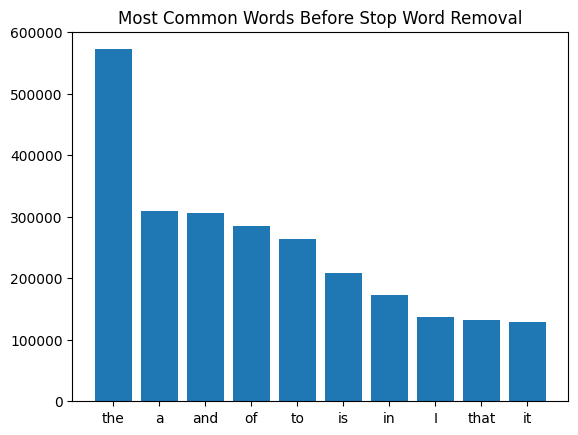

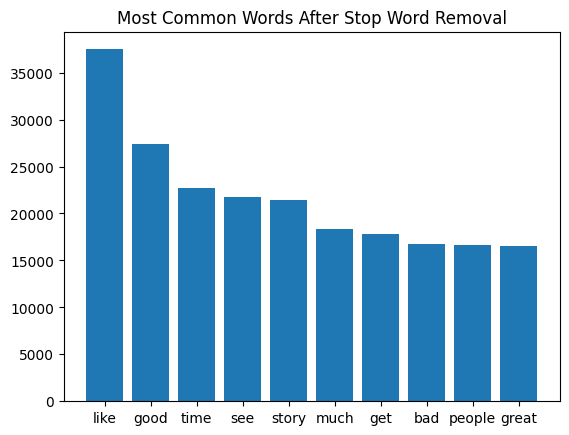

In [8]:
from collections import Counter
import matplotlib.pyplot as plt

word_freq_before = Counter([word for tokens in data['tokens'] for word in tokens])
word_freq_after = Counter([word for tokens in data['clean_tokens'] for word in tokens])

most_common_before = word_freq_before.most_common(10)
words_before, counts_before = zip(*most_common_before)
plt.bar(words_before, counts_before)
plt.title('Most Common Words Before Stop Word Removal')
plt.show()

most_common_after = word_freq_after.most_common(10)
words_after, counts_after = zip(*most_common_after)
plt.bar(words_after, counts_after)
plt.title('Most Common Words After Stop Word Removal')
plt.show()

## Impact of Preprocessing: Word Frequency Before and After
To demonstrate the impact of text preprocessing, we visualized word frequencies before and after stop word removal and custom stop word filtering.

#### Before Preprocessing:

High-Frequency Words: Included punctuation marks (if any remained), HTML-related terms like <br>, and common stop words such as "the," "and," "movie," and "film."
Example Words: "movie," "film," "the," "and," "i," "it," "was," "this," "good," "bad."

#### After Preprocessing:

Refined Words: Focused on more meaningful terms that provide insight into the sentiment and content of the reviews.
Example Words: "good," "bad," "story," "plot," "acting," "time," "characters," "would," "recommend," "director."

After preprocessing, there was a significant reduction in common and non-informative words, which resulted in a cleaner dataset. The removal of generic terms such as "movie" and "film," along with standard stop words, allowed for a shift in focus towards words that are more indicative of sentiment and specific aspects of the movies, such as "good," "bad," "story," and "acting." This refinement helps in capturing more meaningful insights related to the review content and sentiment.

## Conclusion

In conclusion, text preprocessing is a critical step in preparing raw text data for analysis. By removing HTML tags, line breaks, and punctuation, as well as performing tokenization, stop word removal, stemming, and lemmatization, we were able to transform the noisy, unstructured review text into clean, standardized data. Tailoring the stop word list to include domain-specific terms like "movie" and "film" significantly improved the relevance of the remaining words, focusing on terms that provide more insight into sentiment and specific aspects of the movies. Additionally, balancing stemming and lemmatization helped reduce word complexity while maintaining context. The preprocessing steps effectively prepared the dataset for advanced NLP tasks, such as sentiment analysis, topic modeling, and machine learning-based sentiment classification, ensuring that the data is structured and optimized for further analysis.